In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ilipy import  Session
from ilipy.database import DistanceCorrelation

In [2]:
run_number = 4
inspection_id='09JBC62FLJZ'
session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

PySettings.cpp(46): ilipy: Build 0.17.2.10867 5d2ea142f2 release-ili-0.17 'Tue Jul 22 21:50:18 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(168): WebSoc

In [4]:
import pandas as pd
from typing import Dict
from ilipy.sensors import ArmAngleLookup
from ilipy import ClipTypes, OdometerTicks, OdometerTickRange, ViewDistance
from statsmodels.tsa.seasonal import seasonal_decompose
def extract_arm_angles(
    session, dist_corr, view_distance_range_m, tick_sampling_interval=10
):

    all_arms = {}
    clips = session.get_clips_by_type(ClipTypes.ChannelData)

    start_vd, end_vd = view_distance_range_m

    for clip in clips:
        # 1) map view-distances -> odometer-ticks for this clip
        try:
            tick_start = dist_corr.get_odometer_ticks_from_view_distance(
                clip, ViewDistance(start_vd)
            )
            tick_end = dist_corr.get_odometer_ticks_from_view_distance(
                clip, ViewDistance(end_vd)
            )
        except Exception:
            continue  # clip can’t map those distances

        query_range = OdometerTickRange(tick_start, tick_end)
        clip_range = clip.odometer_tick_range

        # 2) skip clips with no raw-tick overlap
        if (
            clip_range.max.value < query_range.min.value
            or clip_range.min.value > query_range.max.value
        ):
            continue

        # 3) clamp to the actual overlapping integer ticks
        lo = max(clip_range.min.value, tick_start.value)
        hi = min(clip_range.max.value, tick_end.value)
        if hi <= lo:
            continue

        # 4) sample every tick_sampling_interval ticks
        arm_lookup = ArmAngleLookup(session, clip)
        rows = []
        for tick in range(int(lo), int(hi) + 1, tick_sampling_interval):
            odot = OdometerTicks(tick)
            angle = arm_lookup.get_axis_angle_from_odometer_ticks(odot)
            #vd_m = dist_corr.get_view_distance_from_odometer_ticks(clip, odot).value
            rows.append(
                {
                    "track_index": clip.track_index,
                    # "odometer_tick": tick,
                    #"view_distances_m": vd_m,
                    "arm_axis_angles_rad": angle,
                }
            )

        # 5) only keep clips where we actually got samples
        if rows:
            all_arms[clip.clip_id] = pd.DataFrame(rows)

    return all_arms


def create_arm_array(
    arm_data_dict: Dict[str, pd.DataFrame],
    num_tracks: int = 20,
    num_tick_samples: int = 500,
    normalize: str = "patch",
) -> np.ndarray:
    all_dfs = pd.concat(arm_data_dict.values(), ignore_index=True)
    grouped = all_dfs.groupby("track_index")["arm_axis_angles_rad"]
    groups = {track_idx: group.values for track_idx, group in grouped}

    arm_array = np.zeros((num_tracks, num_tick_samples), dtype=np.float32)

    for i in range(num_tracks):
        if i in groups:
            values = groups[i]
            length = min(num_tick_samples, len(values))
            arm_array[i, :length] = values[:length]
            if length < num_tick_samples and length > 0:
                arm_array[i, length:] = values[length - 1]

    if normalize == "std":
        arm_array = arm_array - arm_array.mean(axis=1, keepdims=True)
        max_std_index = np.argmax(np.std(arm_array, axis=1, keepdims=True))

        row_min = arm_array.min(axis=1, keepdims=True)[max_std_index]
        row_max = arm_array.max(axis=1, keepdims=True)[max_std_index]
        denom = np.where((row_max - row_min) == 0, 1, row_max - row_min)
        arm_array = (arm_array - row_min) / denom
           
        return arm_array
    elif normalize == "patch":

        row_min = arm_array.min(axis=1, keepdims=True)
        row_max = arm_array.max(axis=1, keepdims=True)
        denom = np.where((row_max - row_min) == 0, 1, row_max - row_min)
        arm_array = (arm_array - row_min) / denom
        return arm_array
    else: #not normalize
        return arm_array

In [ ]:
view_dist = 147828.385 -0.15
length = 0.3
vd_range = (view_dist, view_dist + length)
tick_sampling_interval = 10

DbHealthCheck.cpp(146): Database service health check complete: Healthy


In [ ]:
def min_max_normalize(arr):
    arr_min = arr.min(axis=1, keepdims=True)
    arr_max = arr.max(axis=1, keepdims=True)
    denom = np.where((arr_max - arr_min) == 0, 1, arr_max - arr_min)
    return (arr - arr_min) / denom

def z_normalize(arr, axis=None):
    arr_mean = arr.mean(axis=axis, keepdims=True)
    arr_std = arr.std(axis=axis, keepdims=True)
    return (arr - arr_mean) / np.where(arr_std == 0, 1, arr_std)

def moving_average(x, window_size=100):
    return np.convolve(x, np.ones(window_size)/window_size, mode='same')



arm_angles = extract_arm_angles(session, dist_corr, vd_range, tick_sampling_interval=tick_sampling_interval)
# arm_angles_samples = extract_arm_angles(session=session, dist_corr=dist_corr,
#     view_distance_range_m=(
#         view_dist - 50 / 2,
#         view_dist + 50 / 2,
#     ),
#     tick_sampling_interval=tick_sampling_interval,
# )
num_tick_samples = int(length * 10000 / tick_sampling_interval)
img_patch = create_arm_array(
    arm_angles,
    num_tracks=20,
    num_tick_samples=num_tick_samples,
    normalize="patch",
)
print(img_patch.shape)
img_not_normalized = create_arm_array(
    arm_angles,
    num_tracks=20,
    num_tick_samples=num_tick_samples,
    normalize="",
)

#img_s = np.apply_along_axis(moving_average, 1, img, window_size=3)
img_norm = min_max_normalize(img_patch)

img_z1 = z_normalize(img_norm)
img_z2 = z_normalize(img_patch, axis=1)
img_z3 = z_normalize(img_z2)

# row_diffs = np.diff(img, axis=0, n=0)
# row_diffs_norm = min_max_normalize(row_diffs)
# row_diffs_z = z_normalize(row_diffs_norm)


(20, 300)


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


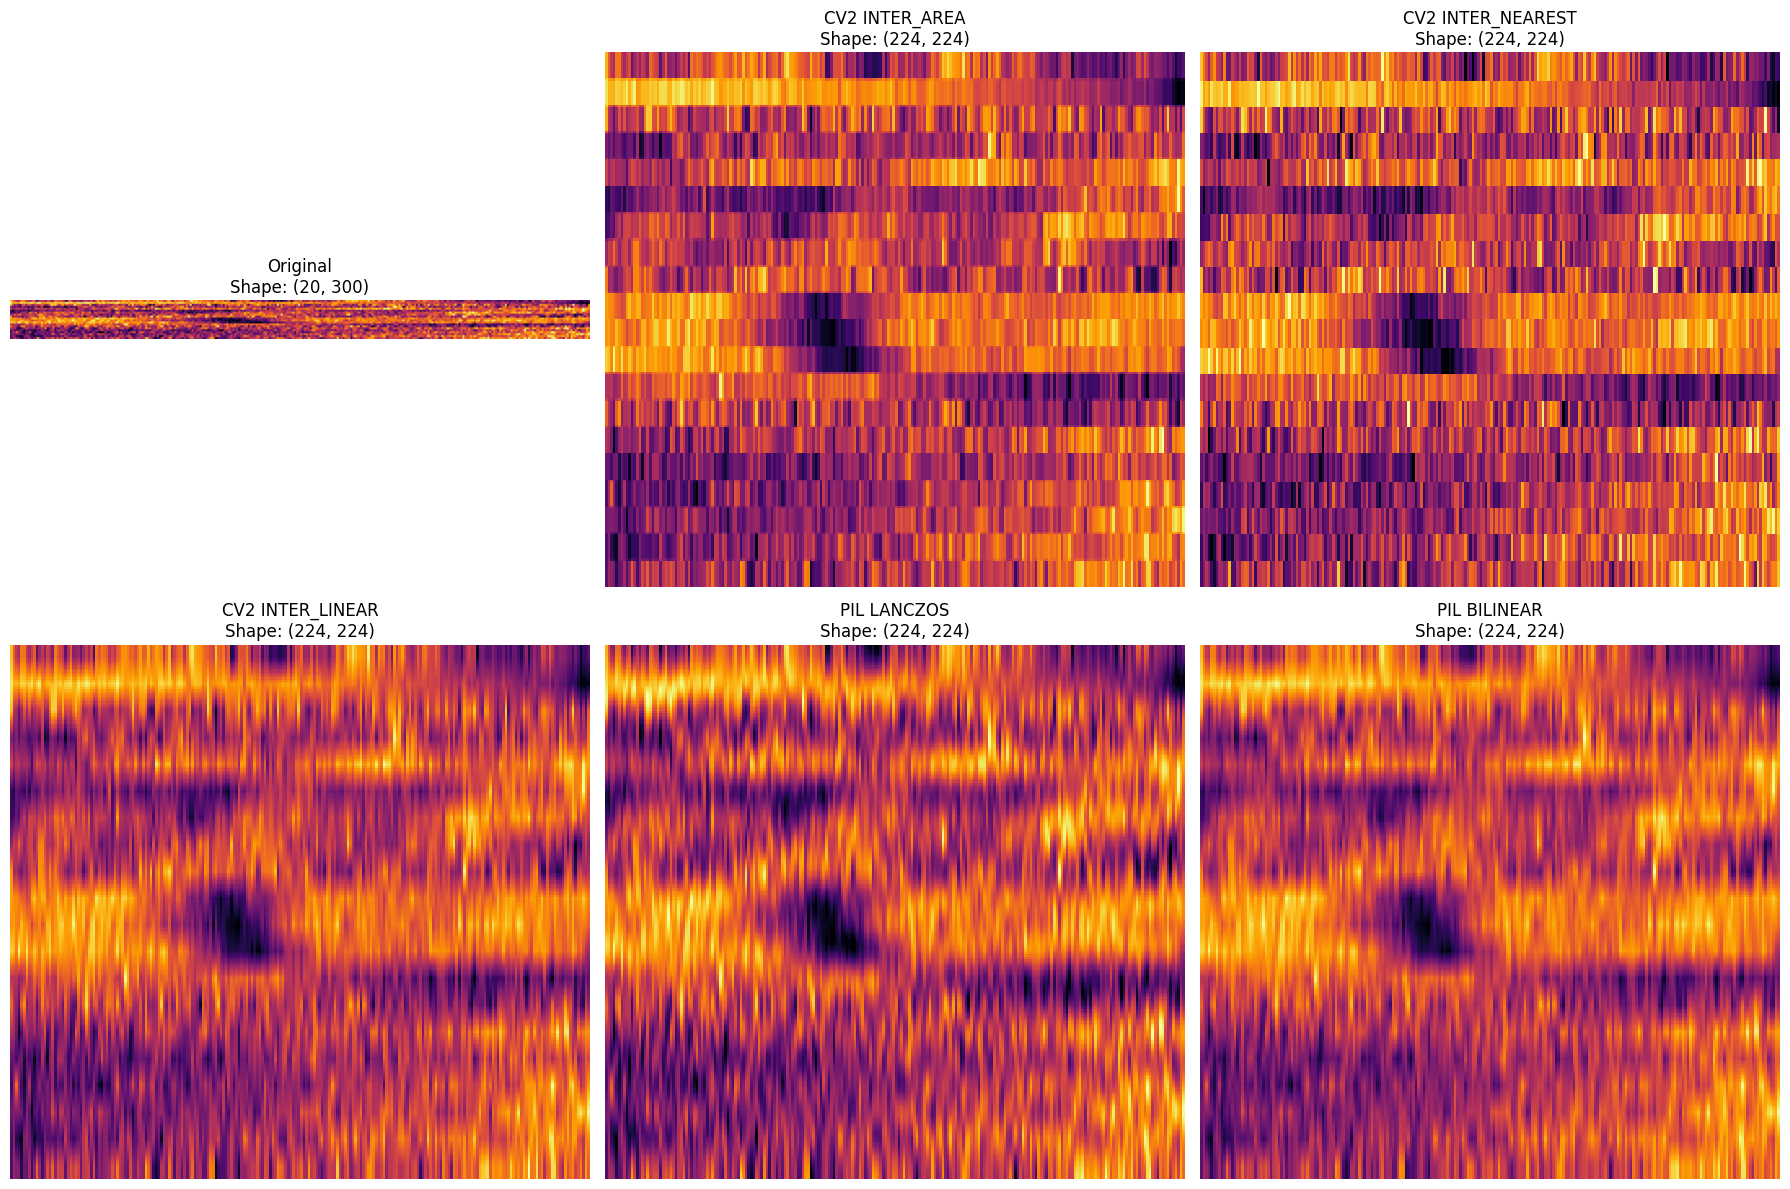

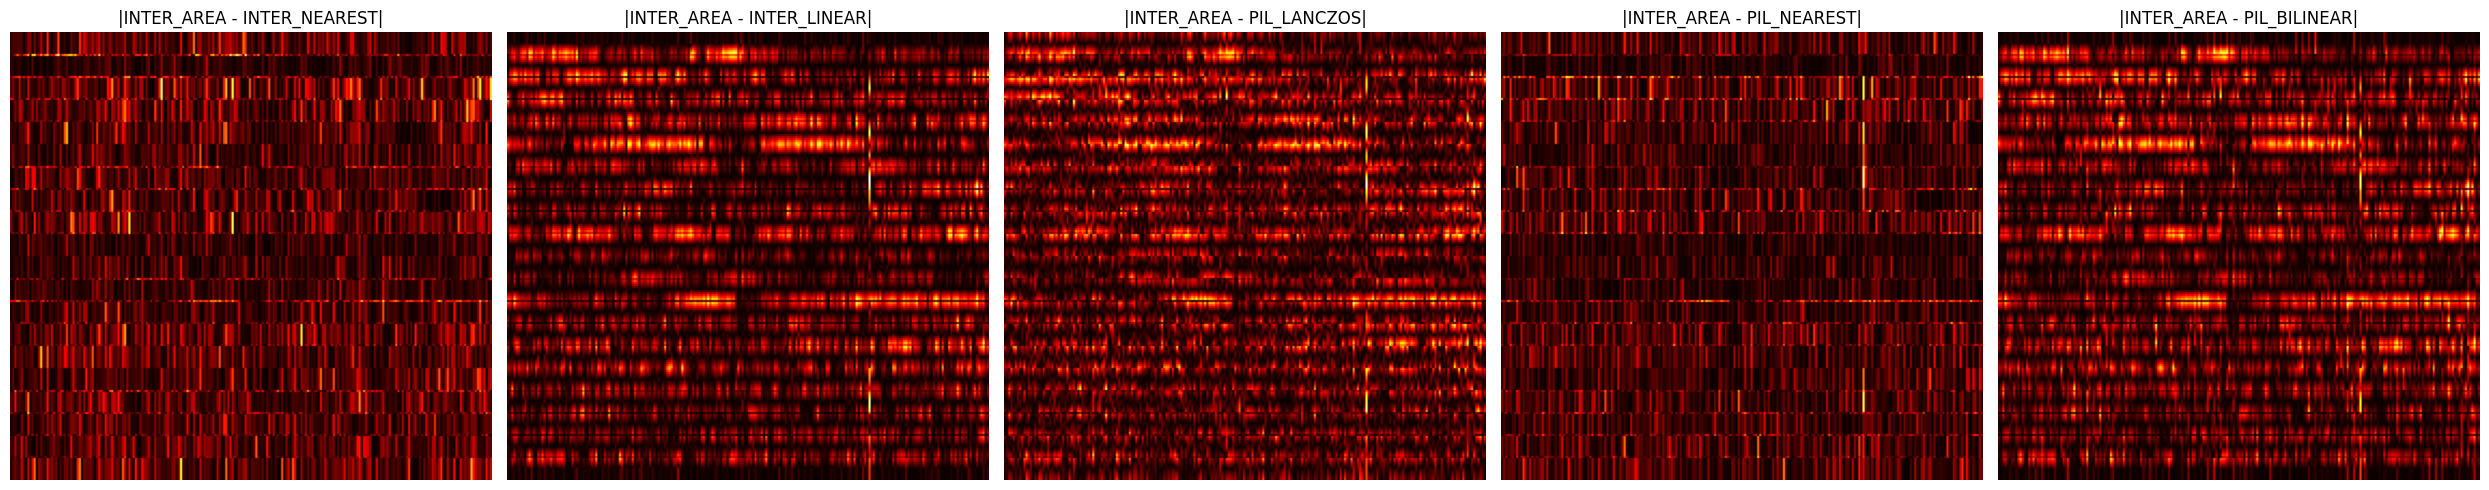

Resize Method Comparison:
Original shape: (20, 300)
Target shape: (224, 224)

Value ranges (min, max, mean):
Original:        (0.000, 1.000, 0.524)
CV2 INTER_AREA:  (0, 255, 133.3)
CV2 INTER_NEAREST: (0, 255, 133.0)
CV2 INTER_LINEAR: (2, 253, 133.1)
PIL LANCZOS:     (0, 255, 133.2)
PIL NEAREST:     (0, 255, 132.7)
PIL BILINEAR:    (2, 246, 133.2)


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.c

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def show_resize_comparison(img_patch):
    """
    Compare different resizing methods for img_patch
    """
    original_shape = img_patch.shape
    target_size = (224, 224)  # (width, height) for cv2 and PIL
    
    # Convert to uint8 for better visualization (scale 0-255)
    img_uint8 = (img_patch * 255).astype(np.uint8)
    
    # Method 1: OpenCV with INTER_AREA (good for downsampling)
    img_cv2_area = cv2.resize(img_uint8, target_size, interpolation=cv2.INTER_AREA)
    
    # Method 2: OpenCV with INTER_NEAREST (preserves exact pixel values)
    img_cv2_nearest = cv2.resize(img_uint8, target_size, interpolation=cv2.INTER_NEAREST)
    
    # Method 3: OpenCV with INTER_LINEAR (bilinear interpolation)
    img_cv2_linear = cv2.resize(img_uint8, target_size, interpolation=cv2.INTER_LINEAR)
    
    # Method 4: PIL with LANCZOS (high quality, smooth)
    img_pil = Image.fromarray(img_uint8)
    img_pil_lanczos = np.array(img_pil.resize(target_size, Image.LANCZOS))
    
    # Method 5: PIL with NEAREST (same as cv2 nearest)
    img_pil_nearest = np.array(img_pil.resize(target_size, Image.NEAREST))
    
    # Method 6: PIL with BILINEAR (smooth, medium quality)
    img_pil_bilinear = np.array(img_pil.resize(target_size, Image.BILINEAR))
    
    # Plot comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Original
    axes[0, 0].imshow(img_patch, cmap='inferno')#, aspect='auto', interpolation='nearest')
    axes[0, 0].set_title(f'Original\nShape: {original_shape}')
    axes[0, 0].axis('off')
    
    # CV2 INTER_AREA
    axes[0, 1].imshow(img_cv2_area, cmap='inferno', aspect='auto', interpolation='nearest')
    axes[0, 1].set_title(f'CV2 INTER_AREA\nShape: {img_cv2_area.shape}')
    axes[0, 1].axis('off')
    
    # CV2 INTER_NEAREST
    axes[0, 2].imshow(img_cv2_nearest, cmap='inferno', aspect='auto', interpolation='nearest')
    axes[0, 2].set_title(f'CV2 INTER_NEAREST\nShape: {img_cv2_nearest.shape}')
    axes[0, 2].axis('off')
    
    # CV2 INTER_LINEAR
    axes[1, 0].imshow(img_cv2_linear, cmap='inferno', aspect='auto', interpolation='nearest')
    axes[1, 0].set_title(f'CV2 INTER_LINEAR\nShape: {img_cv2_linear.shape}')
    axes[1, 0].axis('off')
    
    # PIL LANCZOS
    axes[1, 1].imshow(img_pil_lanczos, cmap='inferno', aspect='auto', interpolation='nearest')
    axes[1, 1].set_title(f'PIL LANCZOS\nShape: {img_pil_lanczos.shape}')
    axes[1, 1].axis('off')
    
    # PIL BILINEAR
    axes[1, 2].imshow(img_pil_bilinear, cmap='inferno', aspect='auto', interpolation='nearest')
    axes[1, 2].set_title(f'PIL BILINEAR\nShape: {img_pil_bilinear.shape}')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Show difference maps
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    
    # Differences from INTER_AREA (reference)
    diff_nearest = np.abs(img_cv2_area.astype(float) - img_cv2_nearest.astype(float))
    diff_linear = np.abs(img_cv2_area.astype(float) - img_cv2_linear.astype(float))
    diff_lanczos = np.abs(img_cv2_area.astype(float) - img_pil_lanczos.astype(float))
    diff_pil_nearest = np.abs(img_cv2_area.astype(float) - img_pil_nearest.astype(float))
    diff_bilinear = np.abs(img_cv2_area.astype(float) - img_pil_bilinear.astype(float))
    
    axes[0].imshow(diff_nearest, cmap='hot', aspect='auto')
    axes[0].set_title('|INTER_AREA - INTER_NEAREST|')
    axes[0].axis('off')
    
    axes[1].imshow(diff_linear, cmap='hot', aspect='auto')
    axes[1].set_title('|INTER_AREA - INTER_LINEAR|')
    axes[1].axis('off')
    
    axes[2].imshow(diff_lanczos, cmap='hot', aspect='auto')
    axes[2].set_title('|INTER_AREA - PIL_LANCZOS|')
    axes[2].axis('off')
    
    axes[3].imshow(diff_pil_nearest, cmap='hot', aspect='auto')
    axes[3].set_title('|INTER_AREA - PIL_NEAREST|')
    axes[3].axis('off')
    
    axes[4].imshow(diff_bilinear, cmap='hot', aspect='auto')
    axes[4].set_title('|INTER_AREA - PIL_BILINEAR|')
    axes[4].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("Resize Method Comparison:")
    print(f"Original shape: {original_shape}")
    print(f"Target shape: {target_size}")
    print("\nValue ranges (min, max, mean):")
    print(f"Original:        ({img_patch.min():.3f}, {img_patch.max():.3f}, {img_patch.mean():.3f})")
    print(f"CV2 INTER_AREA:  ({img_cv2_area.min()}, {img_cv2_area.max()}, {img_cv2_area.mean():.1f})")
    print(f"CV2 INTER_NEAREST: ({img_cv2_nearest.min()}, {img_cv2_nearest.max()}, {img_cv2_nearest.mean():.1f})")
    print(f"CV2 INTER_LINEAR: ({img_cv2_linear.min()}, {img_cv2_linear.max()}, {img_cv2_linear.mean():.1f})")
    print(f"PIL LANCZOS:     ({img_pil_lanczos.min()}, {img_pil_lanczos.max()}, {img_pil_lanczos.mean():.1f})")
    print(f"PIL NEAREST:     ({img_pil_nearest.min()}, {img_pil_nearest.max()}, {img_pil_nearest.mean():.1f})")
    print(f"PIL BILINEAR:    ({img_pil_bilinear.min()}, {img_pil_bilinear.max()}, {img_pil_bilinear.mean():.1f})")

# Run the comparison
show_resize_comparison(img_patch)

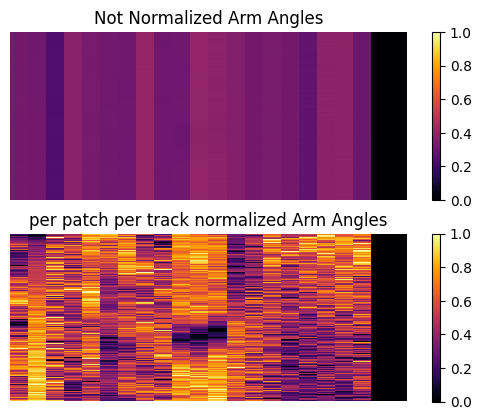

Track 01-009-0V9ZBPQC has 50001 samples


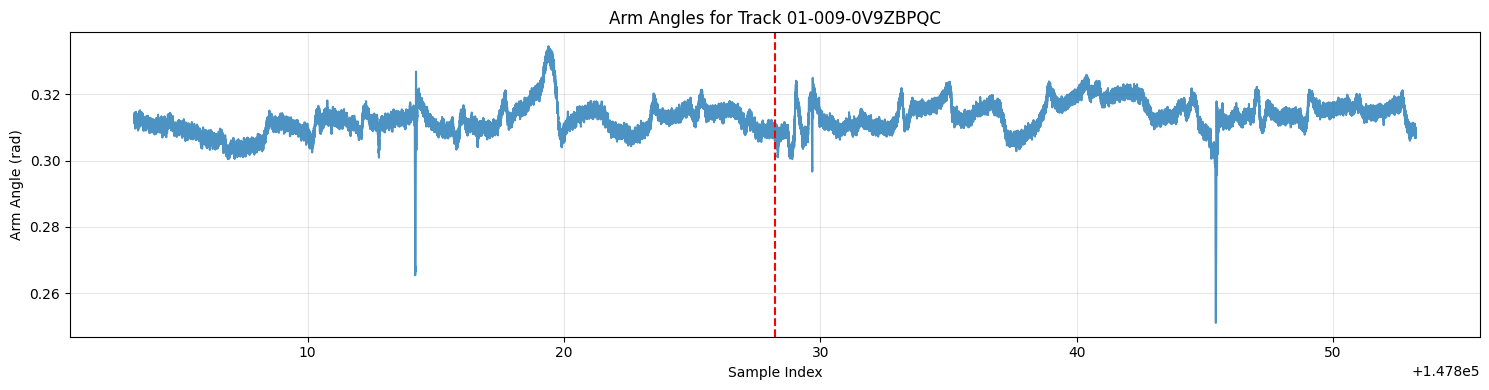

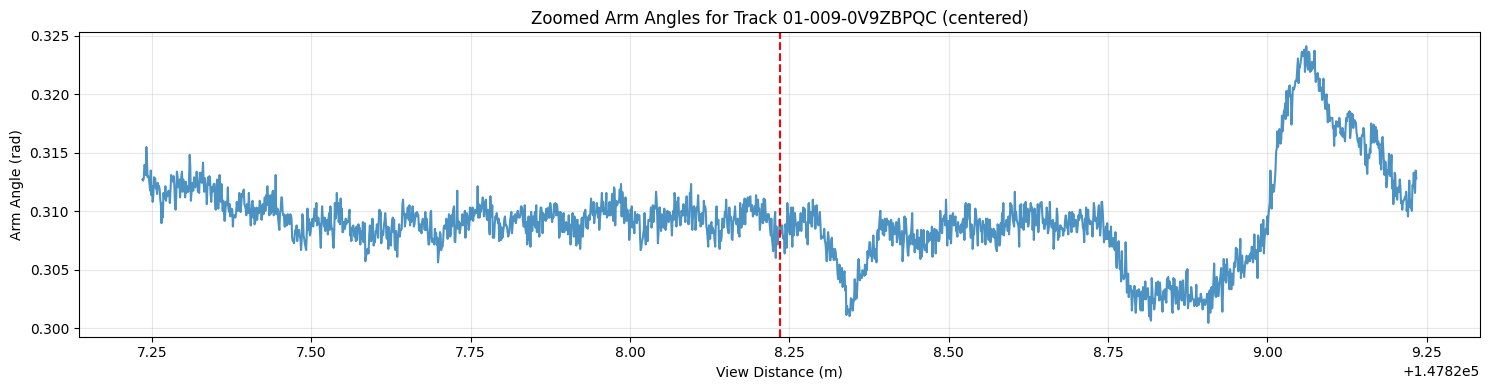

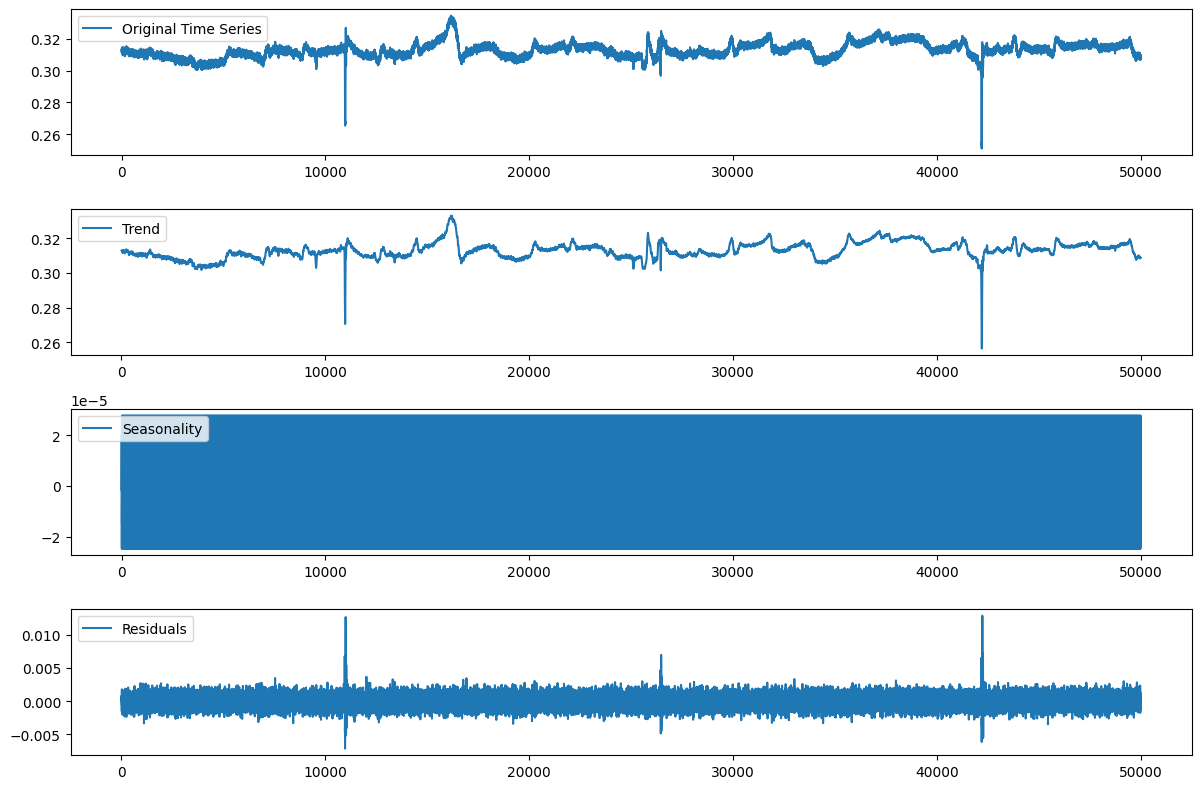

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: 

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

plt.subplot(2, 1, 1)
plt.imshow(
    img_not_normalized.T, cmap="inferno", origin="lower", aspect="auto",
    interpolation="nearest",vmin=0, vmax=1
)
plt.axis("off")
plt.colorbar()
plt.title("Not Normalized Arm Angles")

plt.subplot(2, 1, 2)
plt.imshow(
    img_patch.T, cmap="inferno", origin="lower", aspect="auto",
    interpolation="nearest",
)
plt.axis("off")
plt.colorbar()
plt.title("per patch per track normalized Arm Angles")
plt.show()
plt.close()

for k, v in arm_angles_samples.items():
    if k=="01-009-0V9ZBPQC":
        print(f"Track {k} has {len(v)} samples")
        plt.figure(figsize=(15, 4))
        ts=v["arm_axis_angles_rad"]
        plt.plot(v["view_distances_m"], v["arm_axis_angles_rad"], label=f"Track {k}", alpha=0.8)


        plt.axvline(x=view_dist, color='red', linestyle='--')
        plt.xlabel("Sample Index")
        plt.ylabel("Arm Angle (rad)")
        plt.title(f"Arm Angles for Track {k}")
        #plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        #zoom in plot around center of previous plot

        center_idx = len(v) // 2
        window = 1000
        start = max(center_idx - window, 0)
        end = min(center_idx + window, len(v))

        plt.figure(figsize=(15, 4))
        plt.plot(
            v["view_distances_m"].iloc[start:end],
            v["arm_axis_angles_rad"].iloc[start:end],
            label=f"Track {k}",
            alpha=0.8
        )
        plt.axvline(x=view_dist, color='red', linestyle='--')
        plt.xlabel("View Distance (m)")
        plt.ylabel("Arm Angle (rad)")
        plt.title(f"Zoomed Arm Angles for Track {k} (centered)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        result_add = seasonal_decompose(ts, model='additive', period=20)

        # Plot the decomposed components
        plt.figure(figsize=(12, 8))
        plt.subplot(411)
        plt.plot(ts, label='Original Time Series')
        plt.legend(loc='upper left')
        plt.subplot(412)
        plt.plot(result_add.trend, label='Trend')
        plt.legend(loc='upper left')
        plt.subplot(413)
        plt.plot(result_add.seasonal, label='Seasonality')
        plt.legend(loc='upper left')
        plt.subplot(414)
        plt.plot(result_add.resid, label='Residuals')
        plt.legend(loc='upper left')
        plt.tight_layout()
        plt.show()